# Figures

In [17]:
import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path
 
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        9,
    "axes.titlesize":   9,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "legend.fontsize":  8,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
 
FULL_W = 7.16   # full page width (inches)
ROW_H  = 2.8    # row height (inches)
 
DATASET_COLORS = {
    "EuroSAT":     "#1f77b4",
    "UCM":         "#ff7f0e",
    "Fish":        "#2ca02c",
    "Marine":      "#d62728",
    "Flowers":     "#9467bd",
    "Flowers102":  "#8c564b",
    "OxfordPets":  "#e377c2",
    "CUB200":      "#7f7f7f",
    "Dissertation":"#bcbd22",
}
 
MODEL_MARKERS = {
    "ViT-B/16":           "o",
    "ViT-L/14@336px":     "s",
    "OpenCLIP-ViT-H-14":  "^",
    "MetaCLIP-ViT-B-16":  "D",
    "SigLIP-ViT-B-16":    "P",
    "RN50x4":             "X",
}
 
MODEL_SHORT = {
    "ViT-B/16":           "ViT-B/16",
    "ViT-L/14@336px":     "ViT-L/14",
    "OpenCLIP-ViT-H-14":  "OC-ViT-H-14",
    "MetaCLIP-ViT-B-16":  "MC-ViT-B-16",
    "SigLIP-ViT-B-16":    "SigLIP-B-16",
    "RN50x4":             "RN50x4",
}
 
# Dataset display order (most interesting first)
DATASETS_ORDERED = [
    "Fish", "EuroSAT", "UCM", "Marine",
    "Flowers102", "OxfordPets", "CUB200", "Flowers", "Dissertation"
]

### Loading the Data

In [18]:
notebook_dir = Path().resolve()
acc_results = notebook_dir.parent / "acc_results"
JSON_PATH = acc_results / "combined.json"
 
with open(JSON_PATH) as f:
    data = json.load(f)
 
datasets = [d for d in DATASETS_ORDERED if d in {e["dataset"] for e in data}]
models   = sorted(set(e["model"] for e in data))
 
print(f"Loaded {len(data)} entries")
print(f"Datasets ({len(datasets)}): {datasets}")
print(f"Models   ({len(models)}):   {models}")
 
def get_entry(model, dataset):
    return next((d for d in data
                 if d["model"] == model and d["dataset"] == dataset), None)

Loaded 48 entries
Datasets (8): ['Fish', 'EuroSAT', 'UCM', 'Marine', 'Flowers102', 'OxfordPets', 'CUB200', 'Dissertation']
Models   (6):   ['MetaCLIP-ViT-B-16', 'OpenCLIP-ViT-H-14', 'RN50x4', 'SigLIP-ViT-B-16', 'ViT-B/16', 'ViT-L/14@336px']


## Baseline accuracy vs Δp scatter

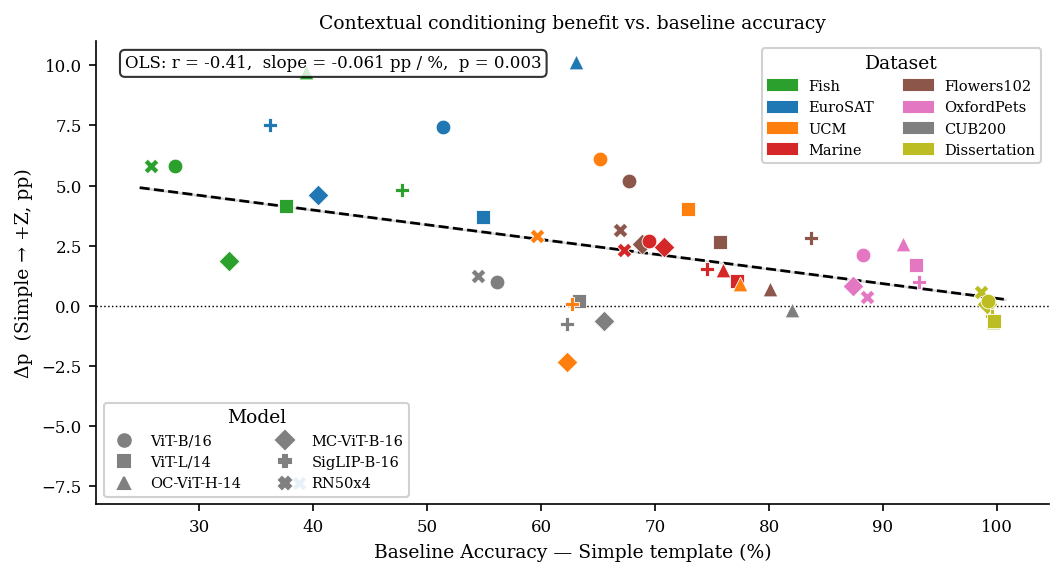

r = -0.414   p = 0.0034   slope = -0.0612 pp per 1% baseline accuracy


In [19]:
fig, ax = plt.subplots(figsize=(FULL_W, ROW_H * 1.4))
 
xs, ys = [], []
for entry in data:
    x  = entry["simple_acc"]
    y  = entry["delta_p_stats"]["delta_p"]
    ds = entry["dataset"]
    m  = entry["model"]
    ax.scatter(x, y,
               color=DATASET_COLORS.get(ds, "grey"),
               marker=MODEL_MARKERS.get(m, "o"),
               s=50, zorder=3,
               edgecolors="white", linewidths=0.4)
    xs.append(x)
    ys.append(y)
 
xs, ys = np.array(xs), np.array(ys)
 
# OLS regression line + 95% CI band
slope, intercept, r, p, se = stats.linregress(xs, ys)
x_line = np.linspace(xs.min() - 1, xs.max() + 1, 300)
y_line = slope * x_line + intercept
p_str  = "<0.001" if p < 0.001 else f"{p:.3f}"
 
ax.plot(x_line, y_line, "k--", linewidth=1.3, zorder=2)
 
n      = len(xs)
se_y   = np.sqrt(se**2 * ((x_line - xs.mean())**2
                 / ((xs - xs.mean())**2).sum() + 1/n))
t_crit = stats.t.ppf(0.975, df=n - 2)
ax.fill_between(x_line,
                y_line - t_crit * se_y,
                y_line + t_crit * se_y,
                alpha=0.12, color="black", zorder=1)
 
ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
 
# Annotation with stats
ax.text(0.03, 0.97,
        f"OLS: r = {r:.2f},  slope = {slope:.3f} pp / %,  p = {p_str}",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
 
# Dataset colour legend
ds_handles = [
    mpatches.Patch(color=DATASET_COLORS[d], label=d)
    for d in DATASETS_ORDERED
    if d in {e["dataset"] for e in data}
]
# Model marker legend
m_handles = [
    Line2D([0],[0], marker=MODEL_MARKERS[m], color="grey",
           linestyle="None", markersize=6, label=MODEL_SHORT[m])
    for m in MODEL_SHORT
    if m in {e["model"] for e in data}
]
 
leg1 = ax.legend(handles=ds_handles, title="Dataset",
                 loc="upper right", ncol=2, framealpha=0.9, fontsize=7)
ax.add_artist(leg1)
ax.legend(handles=m_handles, title="Model",
          loc="lower left", ncol=2, framealpha=0.9, fontsize=7)
 
ax.set_xlabel("Baseline Accuracy — Simple template (%)")
ax.set_ylabel("Δp  (Simple → +Z, pp)")
ax.set_title("Contextual conditioning benefit vs. baseline accuracy")
 
plt.tight_layout()
plt.savefig("fig1_baseline_vs_deltap.pdf")
plt.savefig("fig1_baseline_vs_deltap.png", dpi=300)
plt.show()
print(f"r = {r:.3f}   p = {p:.4f}   slope = {slope:.4f} pp per 1% baseline accuracy")

## Attach Domain Accuracy - Needed for below figure, may not need to be run every time

In [20]:
RESULTS_ROOT = acc_results
 
def attach_domain_acc(data, results_root):
    enriched = 0
    for root, _, files in os.walk(results_root):
        for fname in files:
            if not fname.endswith("_domain.json"):
                continue
            try:
                with open(os.path.join(root, fname)) as f:
                    dom = json.load(f)
                model      = dom.get("model")
                dataset    = dom.get("dataset")
                domain_acc = dom.get("accuracy")
                if model and dataset and domain_acc is not None:
                    for entry in data:
                        if entry["model"] == model and entry["dataset"] == dataset:
                            entry["domain_acc"] = domain_acc
                            enriched += 1
            except Exception as e:
                print(f"  Skipped {fname}: {e}")
    return data, enriched
 
data, n_enriched = attach_domain_acc(data, RESULTS_ROOT)
has_domain = [e for e in data if "domain_acc" in e]
print(f"Attached domain_acc to {n_enriched} entries")
print(f"{len(has_domain)} / {len(data)} entries ready for Fig 2")
if not has_domain:
    print("\nNo domain_acc found. Check RESULTS_ROOT is correct.")
    print("Fig 2 cell will be skipped automatically.")

Attached domain_acc to 48 entries
48 / 48 entries ready for Fig 2


## Pipeline Demonstration - Simple to Domain vs Domain to +Z

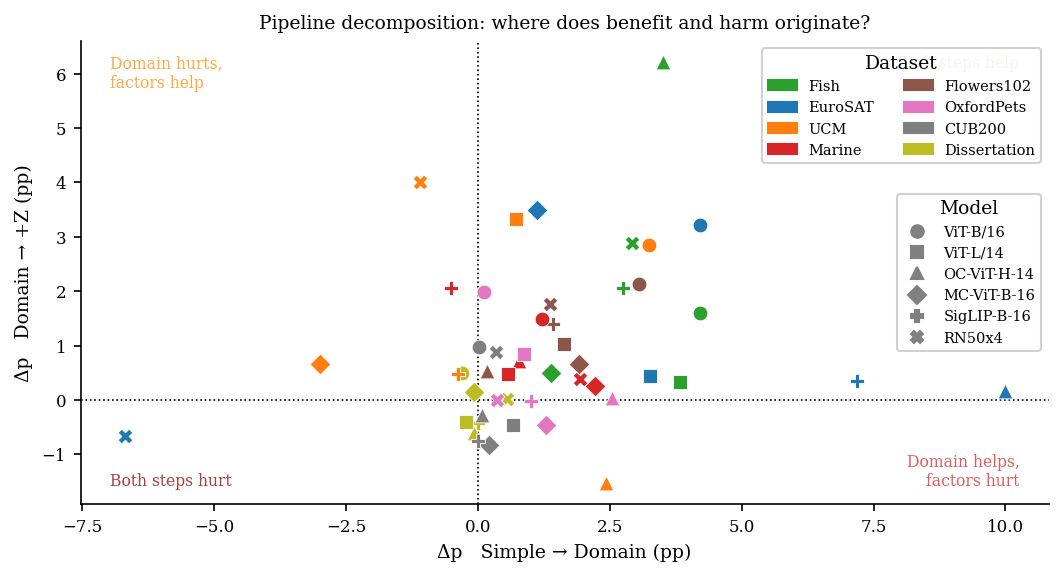


Quadrant breakdown:
  Both steps help:            30  (62%)
  Domain helps, +Z hurts:      9  (19%)
  Domain hurts, +Z helps:      6  (12%)
  Both steps hurt:             3  (6%)


In [21]:
has_domain = [e for e in data if "domain_acc" in e]
 
if not has_domain:
    print("No domain_acc — skipping Fig 2. Fix RESULTS_ROOT in Cell 4 and re-run.")
else:
    fig, ax = plt.subplots(figsize=(FULL_W, ROW_H * 1.4))
 
    for entry in has_domain:
        x  = entry["domain_acc"] - entry["simple_acc"]   # Simple → Domain gain
        y  = entry["plus_z_acc"] - entry["domain_acc"]   # Domain → +Z gain
        ds = entry["dataset"]
        m  = entry["model"]
        ax.scatter(x, y,
                   color=DATASET_COLORS.get(ds, "grey"),
                   marker=MODEL_MARKERS.get(m, "o"),
                   s=50, zorder=3,
                   edgecolors="white", linewidths=0.4)
 
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
 
    # Quadrant shading
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.set_xlim(xlim); ax.set_ylim(ylim)
 
    # Quadrant labels
    kw = dict(transform=ax.transAxes, fontsize=7.5, alpha=0.75)
    ax.text(0.97, 0.97, "Both steps help",
            ha="right", va="top",    color="#2ca02c", **kw)
    ax.text(0.03, 0.97, "Domain hurts,\nfactors help",
            ha="left",  va="top",    color="darkorange", **kw)
    ax.text(0.97, 0.03, "Domain helps,\nfactors hurt",
            ha="right", va="bottom", color="#d62728", **kw)
    ax.text(0.03, 0.03, "Both steps hurt",
            ha="left",  va="bottom", color="darkred", **kw)
 
    # Legends
    ds_handles = [
        mpatches.Patch(color=DATASET_COLORS[d], label=d)
        for d in DATASETS_ORDERED
        if d in {e["dataset"] for e in has_domain}
    ]
    m_handles = [
        Line2D([0],[0], marker=MODEL_MARKERS[m], color="grey",
               linestyle="None", markersize=6, label=MODEL_SHORT[m])
        for m in MODEL_SHORT
        if m in {e["model"] for e in has_domain}
    ]
 
    leg1 = ax.legend(handles=ds_handles, title="Dataset",
                     loc="upper right", ncol=2, framealpha=0.9, fontsize=7)
    ax.add_artist(leg1)
    ax.legend(handles=m_handles, title="Model",
              loc="center right", ncol=1, framealpha=0.9, fontsize=7)
 
    ax.set_xlabel("Δp   Simple → Domain (pp)")
    ax.set_ylabel("Δp   Domain → +Z (pp)")
    ax.set_title("Pipeline decomposition: where does benefit and harm originate?")
 
    plt.tight_layout()
    plt.savefig("fig2_domain_decomposition.pdf")
    plt.savefig("fig2_domain_decomposition.png", dpi=300)
    plt.show()
 
    # Quadrant summary
    q = {"both_help": 0, "domain_only": 0, "factors_only": 0, "both_hurt": 0}
    for e in has_domain:
        x = e["domain_acc"] - e["simple_acc"]
        y = e["plus_z_acc"] - e["domain_acc"]
        if   x >= 0 and y >= 0: q["both_help"]    += 1
        elif x <  0 and y >= 0: q["factors_only"] += 1
        elif x >= 0 and y <  0: q["domain_only"]  += 1
        else:                    q["both_hurt"]    += 1
 
    total = len(has_domain)
    print("\nQuadrant breakdown:")
    print(f"  Both steps help:           {q['both_help']:>3}  ({100*q['both_help']/total:.0f}%)")
    print(f"  Domain helps, +Z hurts:    {q['domain_only']:>3}  ({100*q['domain_only']/total:.0f}%)")
    print(f"  Domain hurts, +Z helps:    {q['factors_only']:>3}  ({100*q['factors_only']/total:.0f}%)")
    print(f"  Both steps hurt:           {q['both_hurt']:>3}  ({100*q['both_hurt']/total:.0f}%)")

## Δp heatmap (dataset × model)

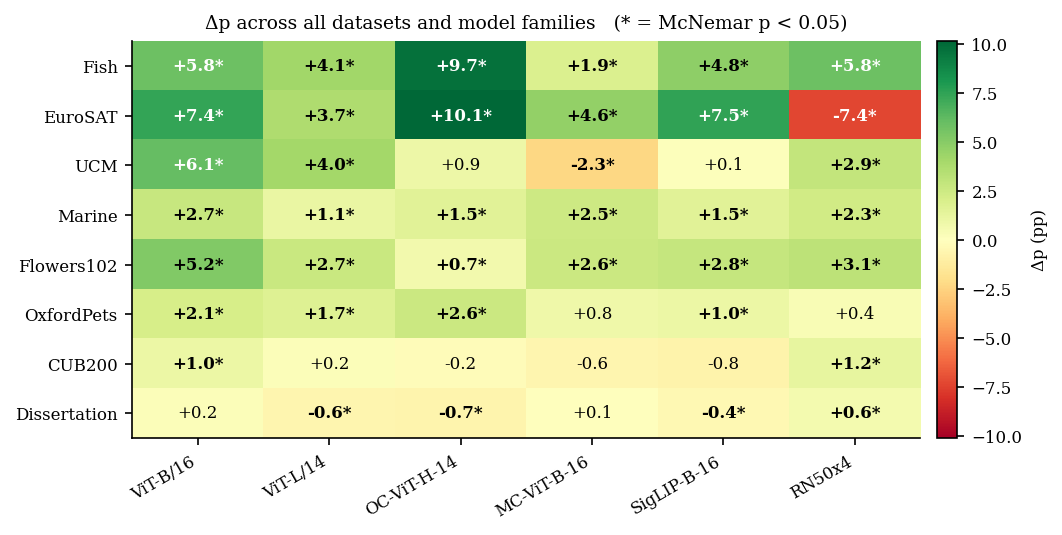

In [22]:
models_ordered = [
    "ViT-B/16", "ViT-L/14@336px", "OpenCLIP-ViT-H-14",
    "MetaCLIP-ViT-B-16", "SigLIP-ViT-B-16", "RN50x4"
]
models_ordered = [m for m in models_ordered if m in {e["model"] for e in data}]
 
matrix = np.full((len(datasets), len(models_ordered)), np.nan)
sig    = np.full((len(datasets), len(models_ordered)), False)
 
for entry in data:
    ds = entry["dataset"]
    m  = entry["model"]
    if ds in datasets and m in models_ordered:
        r = datasets.index(ds)
        c = models_ordered.index(m)
        matrix[r, c] = entry["delta_p_stats"]["delta_p"]
        sig[r, c]    = entry["delta_p_stats"]["significant"] == "True"
 
fig, ax = plt.subplots(figsize=(FULL_W, ROW_H * 1.3))
 
vmax = np.nanmax(np.abs(matrix))
im   = ax.imshow(matrix, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
 
# Cell text
for r in range(len(datasets)):
    for c in range(len(models_ordered)):
        if not np.isnan(matrix[r, c]):
            val  = matrix[r, c]
            star = "*" if sig[r, c] else ""
            fc   = "white" if abs(val) > vmax * 0.55 else "black"
            ax.text(c, r, f"{val:+.1f}{star}",
                    ha="center", va="center", fontsize=8,
                    color=fc,
                    fontweight="bold" if sig[r, c] else "normal")
 
ax.set_xticks(range(len(models_ordered)))
ax.set_xticklabels([MODEL_SHORT[m] for m in models_ordered],
                   rotation=30, ha="right")
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels(datasets)
 
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("Δp (pp)", fontsize=8)
 
ax.set_title("Δp across all datasets and model families   (* = McNemar p < 0.05)")
 
plt.tight_layout()
plt.savefig("fig3_deltap_heatmap.pdf")
plt.savefig("fig3_deltap_heatmap.png", dpi=300)
plt.show()

## Four comparison bar charts

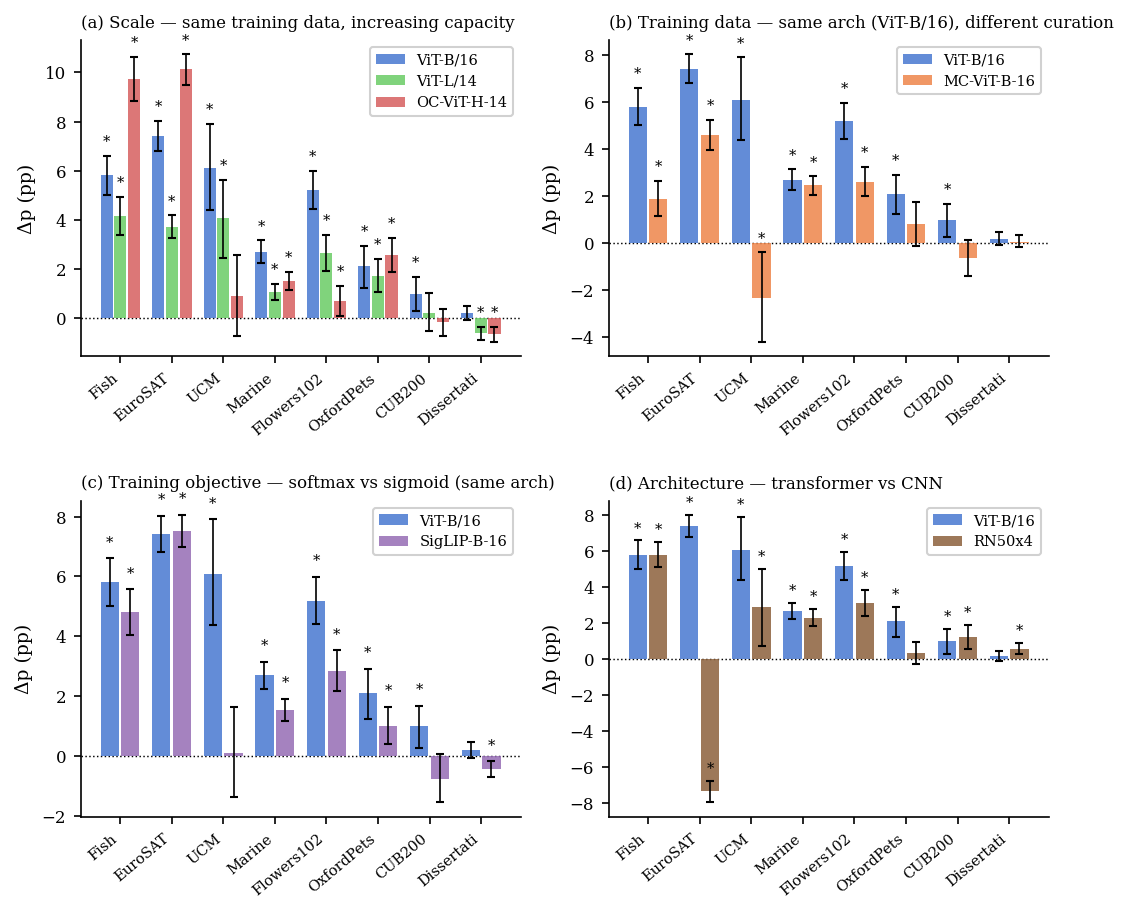

All figures saved.


In [23]:
comparisons = [
    {
        "title":  "(a) Scale — same training data, increasing capacity",
        "models": ["ViT-B/16", "ViT-L/14@336px", "OpenCLIP-ViT-H-14"],
        "colors": ["#4878d0", "#6acc65", "#d65f5f"],
    },
    {
        "title":  "(b) Training data — same arch (ViT-B/16), different curation",
        "models": ["ViT-B/16", "MetaCLIP-ViT-B-16"],
        "colors": ["#4878d0", "#ee854a"],
    },
    {
        "title":  "(c) Training objective — softmax vs sigmoid (same arch)",
        "models": ["ViT-B/16", "SigLIP-ViT-B-16"],
        "colors": ["#4878d0", "#956cb4"],
    },
    {
        "title":  "(d) Architecture — transformer vs CNN",
        "models": ["ViT-B/16", "RN50x4"],
        "colors": ["#4878d0", "#8c613c"],
    },
]
 
fig, axes = plt.subplots(2, 2, figsize=(FULL_W, ROW_H * 2.2))
axes = axes.flatten()
 
for ax, comp in zip(axes, comparisons):
    n_models = len(comp["models"])
    x        = np.arange(len(datasets))
    bar_w    = 0.8 / n_models
 
    for i, (m, col) in enumerate(zip(comp["models"], comp["colors"])):
        vals, lo_errs, hi_errs, sigs = [], [], [], []
 
        for ds in datasets:
            e = get_entry(m, ds)
            if e:
                dp  = e["delta_p_stats"]["delta_p"]
                lo  = e["delta_p_stats"]["delta_p_ci"][0]
                hi  = e["delta_p_stats"]["delta_p_ci"][1]
                sig = e["delta_p_stats"]["significant"] == "True"
            else:
                dp = lo = hi = np.nan
                sig = False
            vals.append(dp)
            lo_errs.append(dp - lo if not np.isnan(dp) else 0)
            hi_errs.append(hi - dp if not np.isnan(dp) else 0)
            sigs.append(sig)
 
        offset = (i - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, vals, bar_w * 0.88,
               color=col, alpha=0.85,
               label=MODEL_SHORT[m], zorder=3)
        ax.errorbar(x + offset, vals,
                    yerr=[lo_errs, hi_errs],
                    fmt="none", color="black",
                    capsize=2, linewidth=0.8, zorder=4)
 
        # Significance stars above each bar
        for xi, (v, hi_e, s) in enumerate(zip(vals, hi_errs, sigs)):
            if s and not np.isnan(v):
                ypos = v + hi_e + 0.3
                ax.text(xi + offset, ypos, "*",
                        ha="center", va="bottom", fontsize=7)
 
    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
    ax.set_xticks(x)
    ax.set_xticklabels([d[:10] for d in datasets],
                       rotation=40, ha="right", fontsize=7)
    ax.set_ylabel("Δp (pp)")
    ax.set_title(comp["title"], fontsize=8, loc="left")
    ax.legend(fontsize=7, framealpha=0.9)
 
fig.tight_layout(h_pad=2.0, w_pad=1.2)
plt.savefig("fig4_four_comparisons.pdf")
plt.savefig("fig4_four_comparisons.png", dpi=300)
plt.show()
print("All figures saved.")